# ISE 571 — Assignment 1, Part II: Geospatial Data and Route Search

**Ahmed Atta** (202621620) · King Fahd University of Petroleum and Minerals

This notebook covers the four coding exercises of Assignment 1:

1. **Dataset** — urban points of interest (POIs) and district boundaries for the Dammam metropolitan area (Dammam, Khobar, Dhahran), extracted from OpenStreetMap.
2. **Visualisation** — choropleth, cartogram, bubble, hexagonal-binning, heat and cluster maps, each followed by the observations drawn from it.
3. **Points of interest** — KFUPM and the Mall of Dhahran, geocoded and marked on a map.
4. **Routing** — routes between the two points on the real drivable road network using BFS, DFS, Dijkstra, hill climbing, A\* and simulated annealing, compared by run time and route length.

Static figures are rendered inline so the notebook reads correctly on GitHub. The interactive Folium versions are written to `maps/` as standalone HTML files.

## 0. Setup

On Google Colab, uncomment the first line to install the geospatial stack. Downloaded OSM data is cached under `data/`, together with the road graph, so re-running the notebook gives the same dataset and the same results without network access.

In [1]:
# !pip install -q osmnx folium mapclassify contextily geopy scikit-learn

import math, time, random, heapq, warnings
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import networkx as nx
import osmnx as ox
import folium
from folium.plugins import HeatMap, MarkerCluster
import contextily as cx
import mapclassify
from scipy.stats import gaussian_kde
from shapely import affinity
from shapely.geometry import box
from sklearn.cluster import DBSCAN
from geopy.geocoders import Nominatim

warnings.filterwarnings("ignore")
ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.requests_timeout = 180
# the main Overpass instance is often overloaded; this public mirror serves the same OSM data
ox.settings.overpass_url = "https://maps.mail.ru/osm/tools/overpass/api"
ox.settings.overpass_rate_limit = False     # the mirror has no /status endpoint

DATA, MAPS, FIGS = Path("data"), Path("maps"), Path("figures")
for d in (DATA, MAPS, FIGS):
    d.mkdir(exist_ok=True)

UTM = 32639                                # WGS 84 / UTM zone 39N (metres)
BASEMAP = cx.providers.Esri.WorldGrayCanvas      # key-free basemap tiles
TILES = "https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}"
TILES_ATTR = "Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ | Data &copy; OpenStreetMap contributors"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})

def map_axes(ax, title=None):
    ax.set_axis_off()
    if title:
        ax.set_title(title, loc="left")

print("osmnx", ox.__version__, "| geopandas", gpd.__version__, "| networkx", nx.__version__)

osmnx 2.1.1 | geopandas 1.1.4 | networkx 3.6.1


## 1. Dataset

**Source.** [OpenStreetMap](https://www.openstreetmap.org) (ODbL), queried through the Overpass API with `osmnx`. Two layers are used:

* **Districts** — administrative boundaries with `admin_level = 10` (the *hayy* level) whose centroid falls inside the study window. They are the spatial units for the choropleth, cartogram and bubble maps.
* **POIs** — amenities, shops, tourism and leisure features inside the districts. Raw OSM tags are grouped into nine service categories, and polygon features (malls, schools, parks) are reduced to their centroid.

The study window is 49.95–50.25 °E, 26.20–26.50 °N, which covers Dammam, Khobar and Dhahran, including KFUPM.

In [2]:
BBOX = (49.95, 26.20, 50.25, 26.50)          # (west, south, east, north)
DISTRICTS_FP, POIS_FP = DATA / "districts.gpkg", DATA / "pois.gpkg"

CATEGORY = {
    "Food & drink": {"amenity": ["restaurant", "fast_food", "cafe", "ice_cream", "food_court"],
                      "shop": ["bakery", "confectionery", "coffee", "pastry"]},
    "Retail":       {"shop": ["supermarket", "mall", "convenience", "department_store", "clothes",
                              "furniture", "hardware", "electronics", "mobile_phone", "optician",
                              "jewelry", "shoes", "perfumery", "cosmetics", "gift", "toys",
                              "books", "sports", "variety_store", "florist", "beauty",
                              "hairdresser", "laundry", "tailor"]},
    "Health":       {"amenity": ["hospital", "clinic", "doctors", "dentist", "pharmacy"]},
    "Education":    {"amenity": ["school", "kindergarten", "college", "university", "library"]},
    "Worship":      {"amenity": ["place_of_worship"]},
    "Finance":      {"amenity": ["bank", "atm", "bureau_de_change"]},
    "Automotive":   {"amenity": ["fuel", "car_wash", "car_rental", "charging_station"],
                     "shop": ["car", "car_repair", "car_parts", "tyres"]},
    "Leisure & tourism": {"tourism": ["hotel", "motel", "apartment", "attraction", "museum",
                                      "theme_park", "gallery", "zoo"],
                          "leisure": ["park", "sports_centre", "fitness_centre", "stadium",
                                      "water_park", "swimming_pool"]},
    "Public services": {"amenity": ["police", "fire_station", "post_office", "community_centre",
                                    "townhall", "courthouse", "social_facility"]},
}

def categorise(row):
    for cat, rules in CATEGORY.items():
        for key, values in rules.items():
            if key in row and row[key] in values:
                return cat
    return None

if DISTRICTS_FP.exists() and POIS_FP.exists():
    districts = gpd.read_file(DISTRICTS_FP)
    pois = gpd.read_file(POIS_FP)
    print("Loaded cached data")
else:
    # --- districts -----------------------------------------------------------
    adm = ox.features_from_bbox(BBOX, {"boundary": "administrative"})
    adm = adm[adm.geom_type.isin(["Polygon", "MultiPolygon"])]
    gov = adm[adm["admin_level"] == "6"][["name:en", "geometry"]].rename(columns={"name:en": "governorate"})
    d = adm[adm["admin_level"] == "10"].copy()
    d = d[d.to_crs(UTM).centroid.to_crs(4326).within(box(*BBOX))]
    d = d.reset_index()[["id", "name", "name:en", "geometry"]]
    d.columns = ["osm_id", "name_ar", "name_en", "geometry"]
    d["name_en"] = d["name_en"].fillna(d["name_ar"])
    rep = d.to_crs(UTM).representative_point().to_crs(4326)
    d["governorate"] = gpd.sjoin(gpd.GeoDataFrame(geometry=rep, crs=4326), gov, how="left",
                                 predicate="within").groupby(level=0)["governorate"].first() \
                          .str.replace(" Governorate", "", regex=False).fillna("Other")
    districts = d.set_crs(4326)

    # --- POIs ----------------------------------------------------------------
    tags = {}
    for rules in CATEGORY.values():
        for k, v in rules.items():
            tags.setdefault(k, []).extend(v)
    # a bounding-box query keeps the Overpass request small; POIs are clipped to districts below
    raw = ox.features_from_bbox(tuple(districts.total_bounds), tags)
    raw = raw.reset_index()
    raw["category"] = raw.apply(categorise, axis=1)
    raw = raw.dropna(subset=["category"])
    raw["osm_type"] = raw[[k for k in ("amenity", "shop", "tourism", "leisure") if k in raw]] \
                          .bfill(axis=1).iloc[:, 0]
    pts = raw.to_crs(UTM)
    pts["geometry"] = pts.geometry.centroid
    pts = pts.to_crs(4326)
    pois = pts[["element", "id", "name", "osm_type", "category", "geometry"]] \
             .rename(columns={"element": "osm_element", "id": "osm_id"})
    pois = gpd.sjoin(pois, districts[["osm_id", "name_en", "governorate", "geometry"]]
                     .rename(columns={"osm_id": "district_id", "name_en": "district"}),
                     how="inner", predicate="within").drop(columns="index_right")
    pois = pois.drop_duplicates(subset=["osm_element", "osm_id"]).reset_index(drop=True)

    districts.to_file(DISTRICTS_FP, driver="GPKG")
    pois.to_file(POIS_FP, driver="GPKG")
    print("Downloaded and cached data")

districts["area_km2"] = districts.to_crs(UTM).area / 1e6
print(f"{len(districts)} districts, {len(pois):,} POIs")
pois.head()

Loaded cached data
134 districts, 2,495 POIs


,osm_element,osm_id,name,osm_type,category,district_id,district,governorate,geometry
0,node,339311918,Holiday Inn,hotel,Leisure & tourism,19120282,Qurtubah,Khobar,POINT (50.17948 26.3409)
1,node,430706653,Farm Superstores 5,supermarket,Retail,20393881,Ad Dawhah Al Janubiyah,Dammam,POINT (50.16218 26.33088)
2,node,440588508,Dhahran Main Fire Station,fire_station,Public services,20393884,Gharb Adh Dhahran,Dammam,POINT (50.12657 26.30858)
3,node,440593782,NaN,florist,Retail,20393884,Gharb Adh Dhahran,Dammam,POINT (50.12916 26.30938)
4,node,440604684,أسواق التميمي,supermarket,Retail,19120272,Al Khubar Ash Shamaliyah,Khobar,POINT (50.21903 26.28916)


,POIs,share,Dammam,Khobar,Qatif
category,,,,,
Retail,630,25.3,398,210,22
Food & drink,477,19.1,289,184,4
Leisure & tourism,375,15.0,241,122,12
Automotive,336,13.5,199,117,20
Worship,331,13.3,256,62,13
Finance,105,4.2,67,34,4
Education,99,4.0,76,14,9
Health,90,3.6,55,31,4
Public services,52,2.1,41,11,0


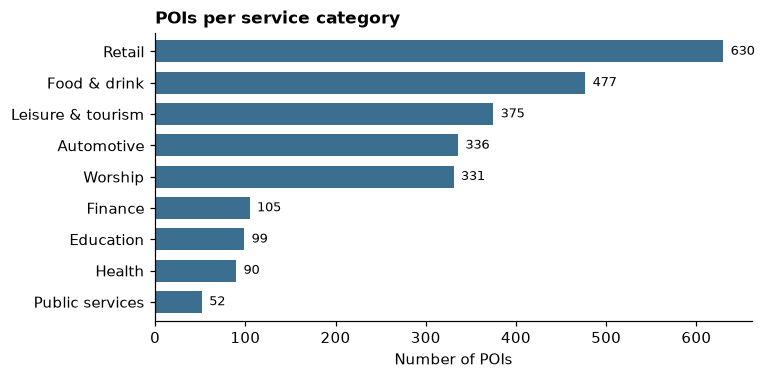

In [3]:
summary = (pois.groupby("category").size().rename("POIs").to_frame()
               .assign(share=lambda t: (100 * t.POIs / t.POIs.sum()).round(1))
               .sort_values("POIs", ascending=False))
by_gov = pd.crosstab(pois["category"], pois["governorate"]).loc[summary.index]
display(summary.join(by_gov))

fig, ax = plt.subplots(figsize=(7, 3.4))
summary["POIs"][::-1].plot.barh(ax=ax, color="#3b6e8f", width=0.7)
for y, v in enumerate(summary["POIs"][::-1]):
    ax.text(v + 8, y, f"{v:,}", va="center", fontsize=8.5)
ax.set_xlabel("Number of POIs"); ax.set_ylabel("")
ax.set_title("POIs per service category", loc="left")
fig.savefig(FIGS / "poi_categories.png"); plt.show()

**Observations — dataset.**

* The cleaned dataset has **2,495 POIs in 134 districts**. Retail (25 %) and food & drink (19 %) together make up almost half of it, followed by leisure/tourism, automotive services and mosques (13–15 % each).
* Health, education and public services are each below 4 %. That is far lower than their real-world share, and it shows the main limitation of OpenStreetMap in Saudi cities: volunteers map commercial places much more completely than institutional ones. The counts below therefore describe *mapped* POIs, and differences between districts partly reflect mapping effort.
* Dammam governorate (which in OSM also contains Dhahran and KFUPM) holds 65 % of the POIs, which matches its larger built-up area. Qatif appears only through a few districts on the edge of the study window.

### Geocoding the two points of interest

Question 3 uses KFUPM and the Mall of Dhahran. Their coordinates come from the Nominatim geocoder (OpenStreetMap's forward geocoder), and the result is cached so the notebook does not depend on the geocoding service after the first run.

In [4]:
GEOCODE_FP = DATA / "geocoded_points.csv"
QUERIES = {
    "KFUPM": "King Fahd University of Petroleum and Minerals, Dhahran, Saudi Arabia",
    "Mall of Dhahran": "Mall of Dhahran, Dhahran, Saudi Arabia",
}
if GEOCODE_FP.exists():
    places = pd.read_csv(GEOCODE_FP, index_col="place")
else:
    geocoder = Nominatim(user_agent="ise571-assignment1")
    rows = []
    for place, q in QUERIES.items():
        loc = geocoder.geocode(q)
        rows.append({"place": place, "address": loc.address, "lat": loc.latitude, "lon": loc.longitude})
        time.sleep(1.1)                     # Nominatim usage policy: max 1 request/s
    places = pd.DataFrame(rows).set_index("place")
    places.to_csv(GEOCODE_FP)
places

,address,lat,lon
place,,,
KFUPM,"جامعة الملك فهد للبترول والمعادن, Elm Lane, غر...",26.305658,50.151302
Mall of Dhahran,"Mall of Dhahran, طريق الملك سعود, الدوحة الجنو...",26.306024,50.169990


## 2. Visualising the data

Most of the maps below are built on the same district-level table: the number of POIs, POI density per km² and the dominant category in each district. Districts smaller than 0.05 km² are kept in the maps but excluded from the density ranking, because a handful of POIs in a very small polygon gives an unstable rate.

In [5]:
counts = pois.pivot_table(index="district_id", columns="category", values="osm_id",
                          aggfunc="count", fill_value=0)
dist = districts.merge(counts, left_on="osm_id", right_index=True, how="left").fillna(
    {c: 0 for c in counts.columns})
cats = list(counts.columns)
dist["total"] = dist[cats].sum(axis=1).astype(int)
dist["density"] = dist["total"] / dist["area_km2"]
dist["dominant"] = np.where(dist["total"] > 0, dist[cats].idxmax(axis=1), "none")
dist_utm = dist.to_crs(UTM)
pois_utm = pois.to_crs(UTM)

ranked = dist[dist.area_km2 >= 0.05].sort_values("density", ascending=False)
display(ranked[["name_en", "governorate", "area_km2", "total", "density", "dominant"]]
        .head(10).round(1).reset_index(drop=True))
print("Districts with no mapped POI:", int((dist.total == 0).sum()), "of", len(dist))

,name_en,governorate,area_km2,total,density,dominant
0,Al Khubar Ash Shamaliyah,Khobar,3.1,121,39.6,Food & drink
1,As Suq,Dammam,0.5,18,34.7,Retail
2,Al Hizam Al Akhdar,Khobar,1.6,51,31.3,Food & drink
3,Al Olaya,Khobar,2.9,77,26.3,Retail
4,Al Badi,Dammam,1.0,23,23.2,Worship
5,Az Zuhur,Dammam,1.6,36,21.9,Retail
6,Al Yarmok,Khobar,1.4,29,20.8,Food & drink
7,Ad Dawasir,Dammam,0.6,12,19.6,Retail
8,Ad Danah Ash Shamaliyah,Dammam,2.1,40,18.7,Leisure & tourism
9,Al Khubar Al Janubiyah,Khobar,2.8,53,18.6,Retail


Districts with no mapped POI: 7 of 134


### 2.1 Choropleth map — POI density per district

Density is classified with **Fisher–Jenks natural breaks** (`mapclassify`) because the distribution is strongly right-skewed and equal intervals would put almost every district in the lowest class.

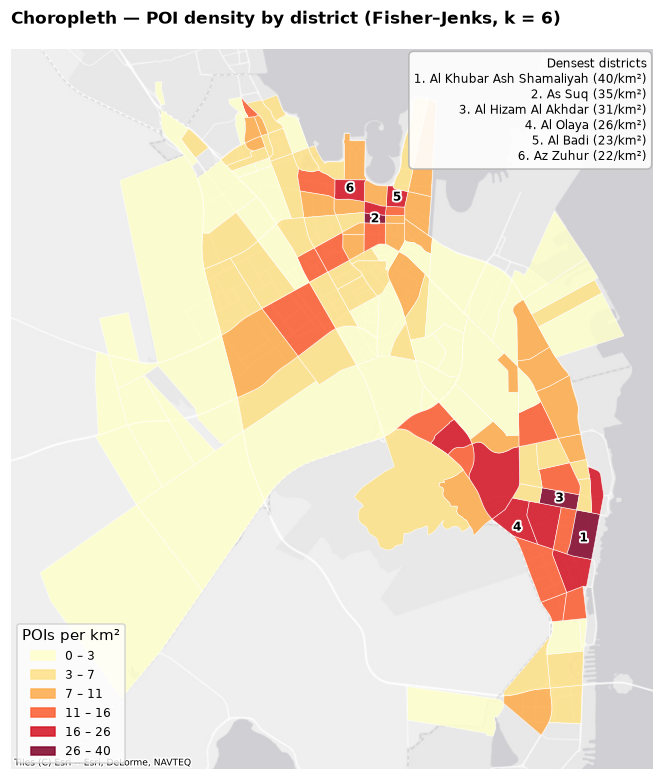

In [6]:
k = 6
fj = mapclassify.FisherJenks(dist_utm["density"], k=k)
labels = [f"{lo:,.0f} – {hi:,.0f}" for lo, hi in zip(np.r_[0, fj.bins[:-1]], fj.bins)]

fig, ax = plt.subplots(figsize=(8.5, 8.5))
dist_utm.assign(cls=fj.yb).plot(column="cls", cmap="YlOrRd", categorical=True, ax=ax,
                                 edgecolor="white", linewidth=0.4, alpha=0.85, legend=False)
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6)
handles = [plt.Rectangle((0, 0), 1, 1, color=plt.cm.YlOrRd(i / (k - 1)), alpha=0.85) for i in range(k)]
ax.legend(handles, labels, title="POIs per km²", loc="lower left", frameon=True, fontsize=8)
top6 = dist_utm[dist_utm.area_km2 >= 0.05].nlargest(6, "density")
for i, (_, r) in enumerate(top6.iterrows(), 1):
    p = r.geometry.representative_point()
    ax.annotate(str(i), (p.x, p.y), fontsize=8, fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax.text(0.99, 0.99, "Densest districts\n" + "\n".join(
            f"{i}. {n} ({d:.0f}/km²)" for i, (n, d) in enumerate(zip(top6.name_en, top6.density), 1)),
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.7", alpha=0.9))
map_axes(ax, "Choropleth — POI density by district (Fisher–Jenks, k = 6)")
fig.savefig(FIGS / "choropleth.png"); plt.show()

m = folium.Map(location=[26.35, 50.12], zoom_start=11, tiles=TILES, attr=TILES_ATTR)
folium.Choropleth(dist[["osm_id", "geometry"]].to_json(), data=dist, columns=["osm_id", "density"],
                  key_on="feature.properties.osm_id", bins=list(np.r_[0, fj.bins]),
                  fill_color="YlOrRd", fill_opacity=0.75, line_weight=0.4,
                  legend_name="POIs per km²").add_to(m)
folium.GeoJson(dist[["name_en", "governorate", "total", "density", "geometry"]].round(1),
               style_function=lambda f: {"fillOpacity": 0, "weight": 0},
               tooltip=folium.GeoJsonTooltip(["name_en", "governorate", "total", "density"],
                                             aliases=["District", "Governorate", "POIs", "POIs/km²"])).add_to(m)
m.save(MAPS / "choropleth.html")

**Observations — choropleth.**

* Density is very uneven. Most of the area falls in the lowest class (0–3 POIs/km²), while a handful of small central districts exceed 20 POIs/km².
* There are **two separate high-density cores**: old downtown Dammam (As Suq, Al Badi, Az Zuhur) in the north, and the Khobar commercial strip (Al Khubar Ash Shamaliyah at about 40 POIs/km², Al Hizam Al Akhdar, Al Olaya) in the south-east. The two are joined by a band of medium density along the main arterial corridors (Ad Dawhah, Al Faisaliyah, Ath Thuqbah).
* The large western and southern districts (industrial areas, Dhahran/Aramco land, new subdivisions) are nearly empty. This is partly real and partly due to missing OSM data.

### 2.2 Cartogram — districts resized by POI density

This is a **non-contiguous (Olson) cartogram**: every district is scaled about its own centroid by a factor $s_i = \sqrt{\rho_i / \rho_{\max}}$, so that its displayed *area* is proportional to its POI density $\rho_i$ while its shape and position are kept. Grey outlines show the true boundaries.

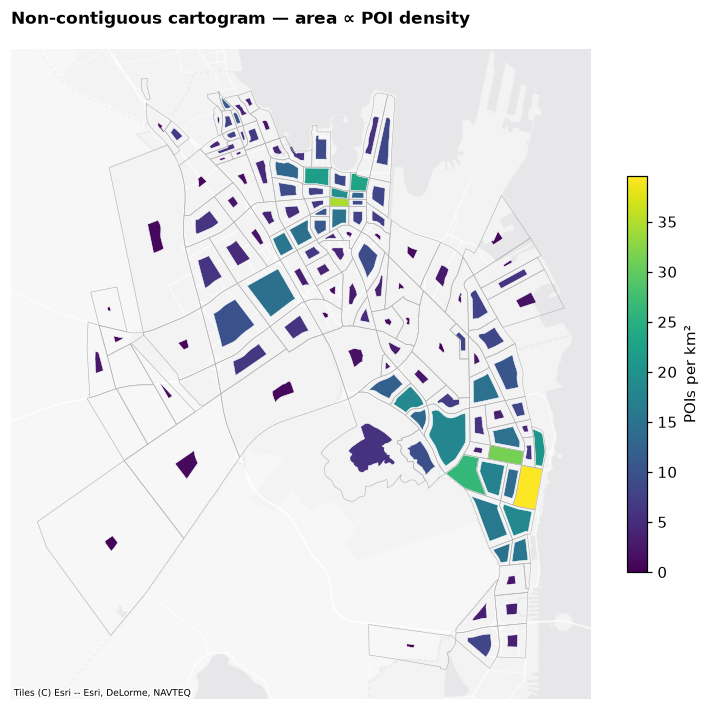

In [7]:
rho =dist_utm["density"].clip(upper=dist_utm["density"].quantile(0.98))
scale = np.sqrt(rho / rho.max())
carto = dist_utm.copy()
carto["geometry"] = [affinity.scale(g, xfact=s, yfact=s, origin="centroid")
                     for g, s in zip(dist_utm.geometry, scale)]

fig, ax = plt.subplots(figsize=(8.5, 8.5))
dist_utm.boundary.plot(ax=ax, color="0.7", linewidth=0.4)
carto.plot(column="density", cmap="viridis", ax=ax, edgecolor="white", linewidth=0.3,
           legend=True, legend_kwds={"label": "POIs per km²", "shrink": 0.55})
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6, alpha=0.5)
map_axes(ax, "Non-contiguous cartogram — area ∝ POI density")
fig.savefig(FIGS / "cartogram.png"); plt.show()

**Observations — cartogram.**

* Resizing districts by density flips the visual message of the ordinary map: the big peripheral polygons, which dominate a normal map, shrink to slivers, while the compact Khobar and downtown-Dammam districts keep most of their size.
* The Khobar core (bright yellow/green) remains a contiguous block, so its high density is a property of the whole area and not of one small polygon. Downtown Dammam is dense but more fragmented.
* The cartogram also exposes the *modifiable areal unit problem*: very small districts (e.g. As Suq, 0.5 km²) reach high densities with only 18 POIs, which is why tiny districts were excluded from the ranking.

### 2.3 Bubble map — POI count and dominant category per district

Each bubble sits on a point inside its district. Bubble area is proportional to the number of POIs and the colour is the district's most frequent category.

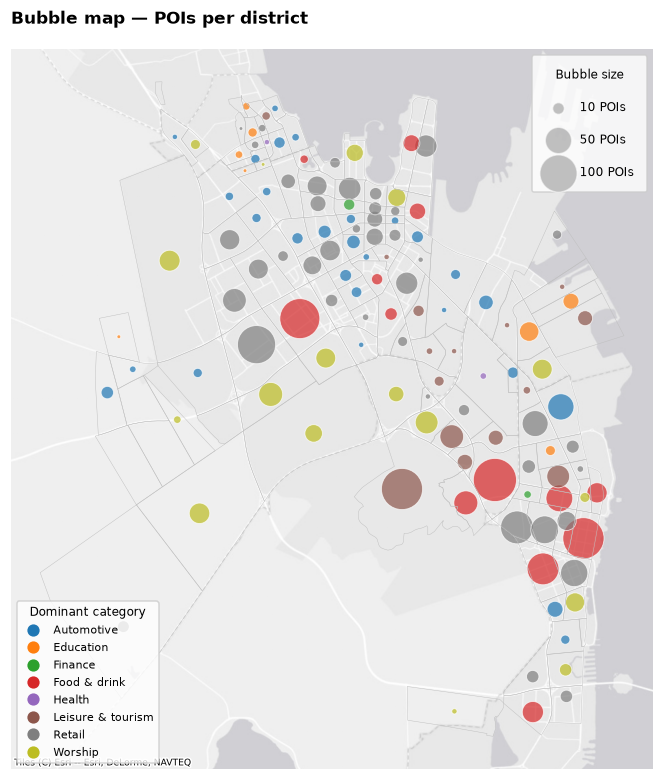

dominant
Retail               42
Automotive           28
Worship              17
Leisure & tourism    15
Food & drink         13
Education             8
Finance               2
Health                2


In [8]:
palette = dict(zip(cats, plt.cm.tab10.colors))
b = dist_utm[dist_utm.total > 0].copy()
b["geometry"] = b.representative_point()
b = b.sort_values("total", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 8.5))
dist_utm.boundary.plot(ax=ax, color="0.75", linewidth=0.3)
ax.scatter(b.geometry.x, b.geometry.y, s=b["total"] * 6, c=b["dominant"].map(palette),
           alpha=0.7, edgecolor="white", linewidth=0.6)
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6)
present = [c for c in cats if c in set(b["dominant"])]
leg1 = ax.legend([Line2D([], [], marker="o", ls="", color=palette[c], ms=7) for c in present], present,
                 title="Dominant category", loc="lower left", fontsize=7.5, title_fontsize=8)
ax.add_artist(leg1)
sizes = [10, 50, 100]
ax.legend([plt.scatter([], [], s=s * 6, color="0.6", alpha=0.6, edgecolor="white") for s in sizes],
          [f"{s} POIs" for s in sizes], loc="upper right", labelspacing=1.6, borderpad=1.1,
          fontsize=8, title="Bubble size", title_fontsize=8)
map_axes(ax, "Bubble map — POIs per district")
fig.savefig(FIGS / "bubble.png"); plt.show()

print(b["dominant"].value_counts().to_string())

**Observations — bubble map.**

* The largest absolute counts are in **Ad Dawhah Al Janubiyah (133 POIs, the district around the Mall of Dhahran)**, Gharb Adh Dhahran (121), Al Khubar Ash Shamaliyah (121) and Al Faisaliyah (114). The largest bubbles therefore sit on the Dhahran–Khobar axis and not in old Dammam.
* **Retail is the dominant category in 42 districts**, mostly in Dammam's grid neighbourhoods. **Food & drink dominates 13 districts**, which cluster in central Khobar (Al Khubar Ash Shamaliyah, Al Hizam Al Akhdar, Al Yarmok, Ath Thuqbah) and around the Mall of Dhahran and KFUPM. This reflects the area's role as the metropolitan dining and leisure destination.
* Automotive services dominate 28 districts, including the industrial *Sinaiyah* zones and several peripheral residential districts where fuel stations and workshops are the only mapped POIs. Mosques dominate 17 residential districts with few mapped shops. The category mix alone is enough to tell apart the commercial, residential and industrial parts of the city.

### 2.4 Hexagonal binning

Hexagonal binning avoids the arbitrary district boundaries: the plane is tiled with regular hexagons (about 1 km across, since the coordinates are in metres) and every hexagon is coloured by the number of POIs it contains. The colour scale is logarithmic because counts span two orders of magnitude.

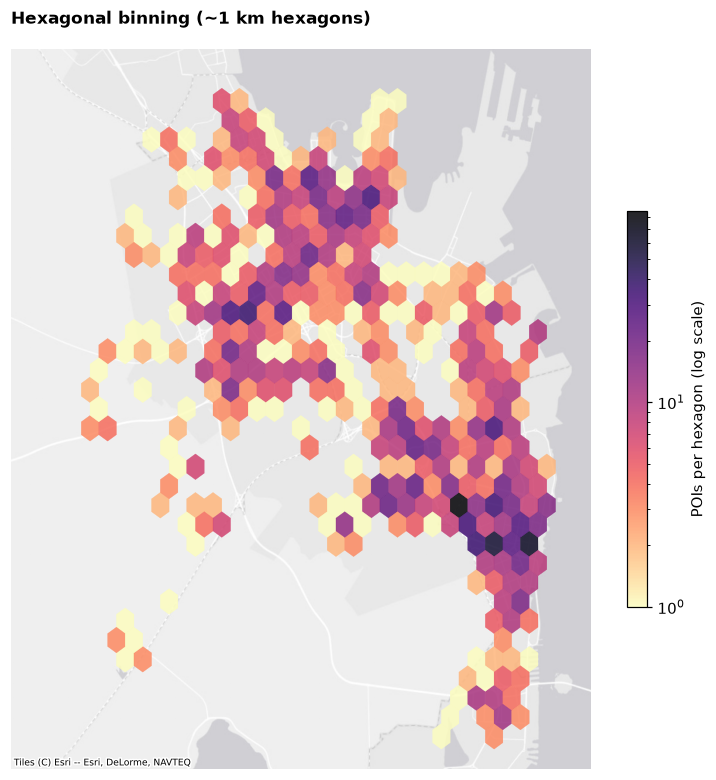

356 occupied hexagons | median 4 POIs | max 86 | top 10% of hexagons hold 39% of POIs


In [9]:
from matplotlib.colors import LogNorm
x, y = pois_utm.geometry.x.values, pois_utm.geometry.y.values
xmin, ymin, xmax, ymax = dist_utm.total_bounds
fig, ax = plt.subplots(figsize=(8.5, 8.5))
hb = ax.hexbin(x, y, gridsize=int((xmax - xmin) / 1000), extent=(xmin, xmax, ymin, ymax),
               mincnt=1, cmap="magma_r", norm=LogNorm(), alpha=0.85, linewidths=0.2)
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6)
fig.colorbar(hb, ax=ax, shrink=0.55, label="POIs per hexagon (log scale)")
map_axes(ax, "Hexagonal binning (~1 km hexagons)")
fig.savefig(FIGS / "hexbin.png"); plt.show()

hex_counts = hb.get_array()
print(f"{len(hex_counts)} occupied hexagons | median {np.median(hex_counts):.0f} POIs | "
      f"max {hex_counts.max():.0f} | top 10% of hexagons hold "
      f"{np.sort(hex_counts)[::-1][:max(1, len(hex_counts)//10)].sum() / hex_counts.sum():.0%} of POIs")

**Observations — hexagonal binning.**

* On a regular ~1 km grid the concentration is even clearer: **356 occupied hexagons, a median of only 4 POIs each, but a maximum of 86**, and the busiest 10 % of hexagons hold about 39 % of all POIs.
* The darkest hexagons form a north–south line through central Khobar, parallel to the coast. A second, weaker band runs diagonally through central Dammam.
* Unlike the choropleth, hexbinning does not depend on district boundaries, so it confirms that the hot spots are real concentrations and not artefacts of the polygon sizes.

### 2.5 Heat map — kernel density of POIs

The static heat map is a Gaussian kernel density estimate (Scott's bandwidth) on a 150 m grid. The interactive version (`maps/heatmap.html`) uses Folium's `HeatMap` plug-in and has one layer per category, so individual services can be compared.

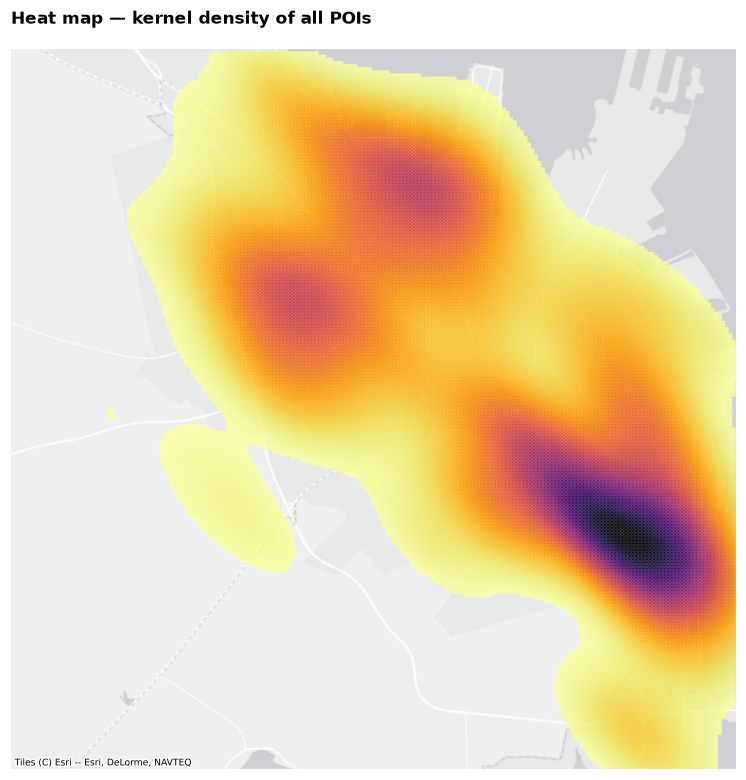

In [10]:
kde = gaussian_kde(np.vstack([x, y]))
gx, gy = np.mgrid[xmin:xmax:150, ymin:ymax:150]
z = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
z = np.ma.masked_less(z, z.max() * 0.03)

fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6)
ax.pcolormesh(gx, gy, z, cmap="inferno_r", alpha=0.6, shading="gouraud")
map_axes(ax, "Heat map — kernel density of all POIs")
fig.savefig(FIGS / "heatmap.png"); plt.show()

m = folium.Map(location=[26.35, 50.12], zoom_start=11, tiles=TILES, attr=TILES_ATTR)
HeatMap(pois[["geometry"]].assign(lat=pois.geometry.y, lon=pois.geometry.x)[["lat", "lon"]].values.tolist(),
        name="All POIs", radius=12, blur=15).add_to(m)
for c in cats:
    sub = pois[pois.category == c]
    HeatMap(np.c_[sub.geometry.y, sub.geometry.x].tolist(), name=c, radius=12, blur=15, show=False).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(MAPS / "heatmap.html")

**Observations — heat map.**

* The kernel density surface has **one dominant peak in central Khobar** and **two secondary peaks in Dammam** (the old downtown and the western districts around Al Faisaliyah).
* A low-density valley separates Dammam from Khobar. It matches the Dhahran/KFUPM/airport-base land and the highway interchanges between the two cities, where there is little street-level commerce.
* In the interactive map, the per-category layers show that food & drink is concentrated in Khobar, while worship and retail are spread much more evenly over the residential districts.

### 2.6 Cluster map

Two views of clustering:

* **DBSCAN** (`eps = 350 m`, `min_samples = 12`) on projected coordinates finds dense commercial clusters and labels isolated POIs as noise. Each cluster is drawn with its convex hull.
* **Marker clustering** in `maps/cluster_map.html` (Folium `MarkerCluster`) aggregates markers by zoom level, so every individual POI can still be inspected.

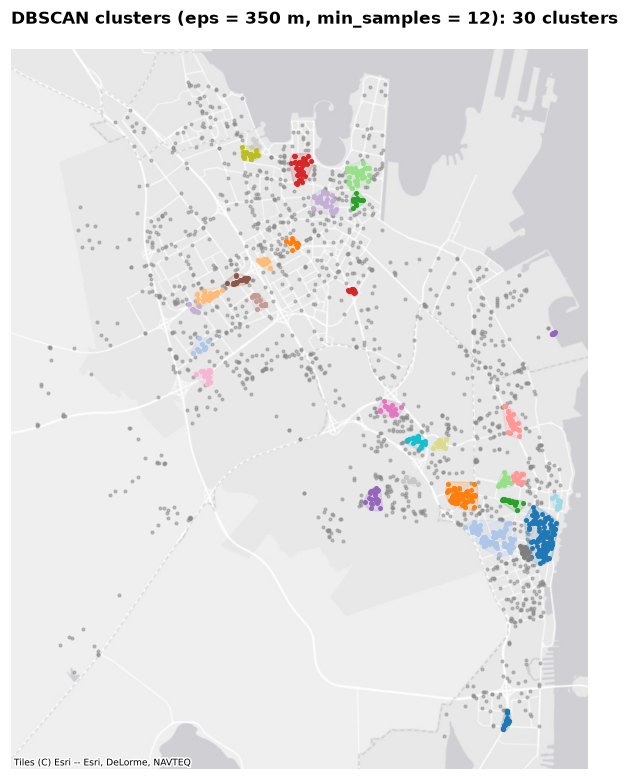

Clustered POIs: 42% | noise: 58%


,POIs,nearest district
cluster,,
2,132,Al Khubar Ash Shamaliyah
6,130,Al Aqrabiyah
11,116,Ad Dawhah Al Janubiyah
9,59,Ohod
10,49,Al Aqrabiyah
5,44,Al Badi
4,43,Az Zuhur
13,39,Ar Rakah Al Janubiyah


In [11]:
X = np.c_[x, y]
labels_ = DBSCAN(eps=350, min_samples=12).fit_predict(X)
pois_utm["cluster"] = labels_
n_clusters = labels_.max() + 1
clusters = (pois_utm[pois_utm.cluster >= 0].dissolve("cluster", aggfunc={"osm_id": "count"})
            .rename(columns={"osm_id": "n"}))
clusters["geometry"] = clusters.convex_hull.buffer(120)
clusters = clusters.sort_values("n", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 8.5))
noise = pois_utm[pois_utm.cluster < 0]
ax.scatter(noise.geometry.x, noise.geometry.y, s=3, color="0.55", alpha=0.5, label="noise")
cmap = plt.cm.tab20
for i, (cid, r) in enumerate(clusters.iterrows()):
    pts = pois_utm[pois_utm.cluster == cid]
    ax.scatter(pts.geometry.x, pts.geometry.y, s=5, color=cmap(i % 20))
    gpd.GeoSeries([r.geometry]).plot(ax=ax, facecolor=cmap(i % 20), alpha=0.18,
                                     edgecolor=cmap(i % 20), linewidth=1)
cx.add_basemap(ax, crs=UTM, source=BASEMAP, attribution_size=6)
map_axes(ax, f"DBSCAN clusters (eps = 350 m, min_samples = 12): {n_clusters} clusters")
fig.savefig(FIGS / "clusters.png"); plt.show()

top = clusters.head(8).copy()
top["nearest district"] = gpd.sjoin_nearest(top.set_geometry(top.centroid)[["n", "geometry"]],
                                            dist_utm[["name_en", "geometry"]])["name_en"] \
                             .groupby(level=0).first()
print(f"Clustered POIs: {(labels_ >= 0).mean():.0%} | noise: {(labels_ < 0).mean():.0%}")
display(top[["n", "nearest district"]].rename(columns={"n": "POIs"}))

m = folium.Map(location=[26.35, 50.12], zoom_start=11, tiles=TILES, attr=TILES_ATTR)
mc = MarkerCluster(name="POIs").add_to(m)
for _, r in pois.iterrows():
    folium.CircleMarker([r.geometry.y, r.geometry.x], radius=4, weight=0, fill=True,
                        fill_color=plt.matplotlib.colors.to_hex(palette[r.category]), fill_opacity=0.9,
                        tooltip=f"{r['name'] if isinstance(r['name'], str) else r.osm_type} ({r.category})"
                        ).add_to(mc)
m.save(MAPS / "cluster_map.html")

**Observations — cluster maps.**

* DBSCAN finds **30 compact clusters that contain 42 % of the POIs**. The other 58 % are scattered neighbourhood services (a corner shop, a mosque, a fuel station) that DBSCAN correctly marks as noise.
* The three largest clusters are the **Khobar city centre (132 POIs)**, **Al Aqrabiyah / Khobar main streets (130)** and **Ad Dawhah Al Janubiyah (116)**. The last one surrounds the Mall of Dhahran and is the destination of the routing exercise.
* Most Dammam clusters are small (40–60 POIs) and sit along commercial streets, which fits a linear, street-front retail pattern rather than malls.
* In the interactive `MarkerCluster` map the cluster sizes update with the zoom level, which makes it convenient for looking up single POIs.

### Summary of the visual analysis

| Map type | Best at showing | Main insight |
|---|---|---|
| Choropleth | Rates per administrative unit | Two dense cores (Khobar, downtown Dammam); most of the area is sparse |
| Cartogram | Relative importance of units | Large peripheral districts matter little; the Khobar core stays prominent |
| Bubble | Absolute counts plus a category | Retail dominates Dammam, food & drink Khobar, automotive the industrial fringe |
| Hexbin | Unit-free concentration | 10 % of the hexagons hold ~39 % of the POIs |
| Heat map | Continuous hot spots | One strong Khobar peak and two Dammam peaks, separated by the Dhahran corridor |
| Cluster | Discrete commercial clusters | 30 clusters; the Mall of Dhahran area is the third largest |

For decisions such as siting a new service, the maps point the same way: the Khobar core is saturated, while the medium-density band between the two cores and the under-served western districts are the gaps. Because OSM coverage is incomplete, any such conclusion should be checked against an official POI register.

## 3. Two points of interest on the map

* **Origin — KFUPM** (King Fahd University of Petroleum and Minerals), Dhahran.
* **Destination — Mall of Dhahran**, King Saud Road, Dhahran.

Straight-line distance: 1,863 m


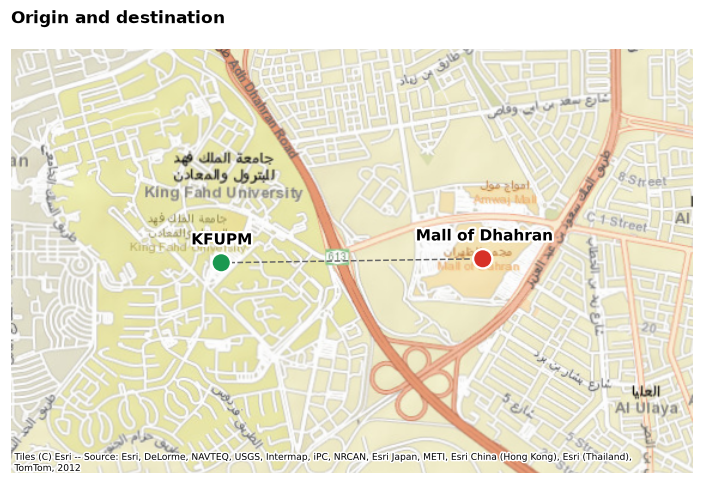

In [12]:
orig_pt = (places.loc["KFUPM", "lat"], places.loc["KFUPM", "lon"])
dest_pt = (places.loc["Mall of Dhahran", "lat"], places.loc["Mall of Dhahran", "lon"])
straight = ox.distance.great_circle(*orig_pt, *dest_pt)
print(f"Straight-line distance: {straight:,.0f} m")

m = folium.Map(location=[(orig_pt[0] + dest_pt[0]) / 2, (orig_pt[1] + dest_pt[1]) / 2],
               zoom_start=14, tiles=TILES, attr=TILES_ATTR)
folium.Marker(orig_pt, tooltip="KFUPM", popup=places.loc["KFUPM", "address"],
              icon=folium.Icon(color="green", icon="graduation-cap", prefix="fa")).add_to(m)
folium.Marker(dest_pt, tooltip="Mall of Dhahran", popup=places.loc["Mall of Dhahran", "address"],
              icon=folium.Icon(color="red", icon="shopping-cart", prefix="fa")).add_to(m)
folium.PolyLine([orig_pt, dest_pt], color="gray", weight=2, dash_array="6",
                tooltip=f"straight line: {straight:,.0f} m").add_to(m)
m.save(MAPS / "points_of_interest.html")

pp = gpd.GeoDataFrame(places, geometry=gpd.points_from_xy(places.lon, places.lat), crs=4326).to_crs(UTM)
fig, ax = plt.subplots(figsize=(8, 5.5))
pp.plot(ax=ax, color=["#1a9850", "#d73027"], markersize=160, edgecolor="white", linewidth=1.5, zorder=3)
for name, r in pp.iterrows():
    ax.annotate(name, (r.geometry.x, r.geometry.y), xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])
ax.plot(pp.geometry.x, pp.geometry.y, ls="--", color="0.4", lw=1)
bx = pp.total_bounds; pad = 1500
ax.set_xlim(bx[0] - pad, bx[2] + pad); ax.set_ylim(bx[1] - pad, bx[3] + pad)
cx.add_basemap(ax, crs=UTM, source=cx.providers.Esri.WorldStreetMap, attribution_size=6)
map_axes(ax, "Origin and destination")
fig.savefig(FIGS / "points_of_interest.png"); plt.show()

## 4. Routing between KFUPM and the Mall of Dhahran

### 4.1 Road network

The drivable network (`network_type="drive"`, one-way streets respected) is downloaded within 3 km of the midpoint of the two locations, and only its largest strongly connected component is kept, so every node can reach every other. Each origin and destination is snapped to the nearest graph node.

For the search algorithms the `MultiDiGraph` is converted to a plain adjacency dictionary `adj[u] = {v: length}`, keeping the shortest of any parallel edges. This keeps the six implementations short and makes the timing comparison fair, because none of them pays NetworkX's attribute-lookup overhead.

In [13]:
mid = ((orig_pt[0] + dest_pt[0]) / 2, (orig_pt[1] + dest_pt[1]) / 2)
GRAPH_FP = DATA / "road_network.graphml"
if GRAPH_FP.exists():
    G = ox.load_graphml(GRAPH_FP)
else:
    G = ox.graph_from_point(mid, dist=3000, network_type="drive", simplify=True)
    G = ox.truncate.largest_component(G, strongly=True)
    ox.save_graphml(G, GRAPH_FP)

orig = ox.distance.nearest_nodes(G, orig_pt[1], orig_pt[0])
dest = ox.distance.nearest_nodes(G, dest_pt[1], dest_pt[0])

adj = {u: {} for u in G.nodes}
for u, v, d in G.edges(data=True):
    if v not in adj[u] or d["length"] < adj[u][v]:
        adj[u][v] = d["length"]
coords = {n: (d["y"], d["x"]) for n, d in G.nodes(data=True)}

print(f"Nodes: {G.number_of_nodes():,} | directed edges: {G.number_of_edges():,}")
print(f"Origin node {orig} is {ox.distance.great_circle(*orig_pt, *coords[orig]):.0f} m from KFUPM; "
      f"destination node {dest} is {ox.distance.great_circle(*dest_pt, *coords[dest]):.0f} m from the mall")

Nodes: 2,749 | directed edges: 6,899
Origin node 6577764261 is 152 m from KFUPM; destination node 9623122408 is 330 m from the mall


### 4.2 Common utilities

* `route_cost` — route length in metres (sum of edge lengths).
* `h(u)` — haversine (great-circle) distance from `u` to the destination. OSM edge lengths are themselves great-circle lengths of the edge geometry, so no road path can be shorter than `h`. The heuristic is therefore **admissible**, and since it satisfies the triangle inequality it is also **consistent**.

In [14]:
R_EARTH = 6_371_009.0

def haversine(a, b):
    (lat1, lon1), (lat2, lon2) = coords[a], coords[b]
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi, dlmb = p2 - p1, math.radians(lon2 - lon1)
    s = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlmb / 2) ** 2
    return 2 * R_EARTH * math.asin(math.sqrt(s))

def route_cost(route):
    return sum(adj[u][v] for u, v in zip(route[:-1], route[1:]))

def backtrack(parent, goal):
    path = [goal]
    while parent[path[-1]] is not None:
        path.append(parent[path[-1]])
    return path[::-1]

### 4.3 Blind search: BFS and DFS

Both are graph searches, so each node is visited at most once. BFS uses a FIFO queue and applies the goal test when a node is generated. It returns the route with the fewest road segments, not the shortest one. DFS uses a LIFO stack and returns the first route it reaches along its current branch. Neither algorithm looks at edge lengths.

In [15]:
def bfs(source, target):
    parent, frontier, expanded = {source: None}, deque([source]), 0
    while frontier:
        u = frontier.popleft(); expanded += 1
        for v in adj[u]:
            if v not in parent:
                parent[v] = u
                if v == target:
                    return backtrack(parent, target), expanded
                frontier.append(v)
    return None, expanded

def dfs(source, target):
    parent, stack, visited, expanded = {source: None}, [source], set(), 0
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u); expanded += 1
        if u == target:
            return backtrack(parent, target), expanded
        for v in adj[u]:
            if v not in visited:
                parent[v] = u
                stack.append(v)
    return None, expanded

### 4.4 Dijkstra and A\*

Both use a binary heap with lazy deletion: stale heap entries are skipped when popped. A\* orders the frontier by $f(n) = g(n) + h(n)$ with the haversine heuristic above. Because $h$ is consistent, a node's $g$ value is final the first time it is popped, exactly as in Dijkstra.

In [16]:
def dijkstra(source, target):
    g, parent, heap, closed = {source: 0.0}, {source: None}, [(0.0, source)], set()
    while heap:
        d, u = heapq.heappop(heap)
        if u in closed:
            continue
        closed.add(u)
        if u == target:
            return backtrack(parent, target), len(closed)
        for v, w in adj[u].items():
            nd = d + w
            if nd < g.get(v, math.inf):
                g[v], parent[v] = nd, u
                heapq.heappush(heap, (nd, v))
    return None, len(closed)

def astar(source, target):
    g, parent, closed = {source: 0.0}, {source: None}, set()
    heap = [(haversine(source, target), 0.0, source)]
    while heap:
        _, gu, u = heapq.heappop(heap)
        if u in closed:
            continue
        closed.add(u)
        if u == target:
            return backtrack(parent, target), len(closed)
        for v, w in adj[u].items():
            nd = gu + w
            if nd < g.get(v, math.inf):
                g[v], parent[v] = nd, u
                heapq.heappush(heap, (nd + haversine(v, target), nd, v))
    return None, len(closed)

### 4.5 Local search: hill climbing and simulated annealing

Here a solution is a complete **route** (a simple path from origin to destination) and the objective is its length.

* **Initial solution.** `random_route` is a randomised depth-first search that tries successors in order of *noisy* straight-line distance to the target: each distance is multiplied by a factor drawn from U(1, 1 + `noise`). This always produces a valid route, but a poor one, because it makes many detours.
* **Neighbourhood operator (sub-path regeneration).** Pick two positions $i < j$ on the current route and replace the segment between them with a new random sub-route from `route[i]` to `route[j]` that avoids the nodes outside the segment. The result is always a valid simple path, and small segments give small moves while long ones give large moves.
* **Hill climbing (steepest ascent on a sampled neighbourhood).** At each iteration `n_neighbours` candidates are generated and the best one replaces the current route only if it is shorter. The search stops after `patience` consecutive iterations without improvement.
* **Simulated annealing.** One neighbour is proposed at a time and accepted with the Metropolis probability $\min\{1, e^{-\Delta/T}\}$, where $\Delta$ is the change in route length in metres. The temperature follows a geometric schedule $T_{k+1} = \alpha T_k$ with a fixed number of moves per temperature, and the best route seen is returned.

Both algorithms get a comparable budget of route evaluations. Because they are stochastic, each is run with 10 random seeds.

In [17]:
def random_route(source, target, rng, noise=1.0, avoid=frozenset()):
    stack, parent, visited = [source], {source: None}, set(avoid) - {source, target}
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        if u == target:
            return backtrack(parent, target)
        nbrs = [v for v in adj[u] if v not in visited]
        nbrs.sort(key=lambda v: haversine(v, target) * rng.uniform(1.0, 1.0 + noise), reverse=True)
        for v in nbrs:                       # best candidate is pushed last, popped first
            parent[v] = u
            stack.append(v)
    return None

def neighbour(route, rng, noise=1.0):
    if len(route) < 3:
        return route
    i, j = sorted(rng.sample(range(len(route)), 2))
    if j - i < 2:
        return route
    avoid = frozenset(route[:i]) | frozenset(route[j + 1:])
    seg = random_route(route[i], route[j], rng, noise, avoid)
    return route if seg is None else route[:i] + seg + route[j + 1:]

def hill_climbing(source, target, seed=0, n_neighbours=10, max_iter=300, patience=30,
                  init_noise=2.0, move_noise=1.0):
    rng = random.Random(seed)
    current = random_route(source, target, rng, init_noise)
    cost = route_cost(current)
    history, evals, stall = [cost], 1, 0
    for _ in range(max_iter):
        cands = [neighbour(current, rng, move_noise) for _ in range(n_neighbours)]
        costs = [route_cost(c) for c in cands]
        evals += n_neighbours
        k = int(np.argmin(costs))
        if costs[k] < cost - 1e-9:
            current, cost, stall = cands[k], costs[k], 0
        else:
            stall += 1
        history.append(cost)
        if stall >= patience:
            break
    return current, evals, history

def simulated_annealing(source, target, seed=0, T0=500.0, Tf=1.0, alpha=0.93, moves_per_T=20,
                        init_noise=2.0, move_noise=1.0):
    rng = random.Random(seed)
    current = random_route(source, target, rng, init_noise)
    cost = route_cost(current)
    best, best_cost = current, cost
    history, evals, T = [cost], 1, T0
    while T > Tf:
        for _ in range(moves_per_T):
            cand = neighbour(current, rng, move_noise)
            c = route_cost(cand); evals += 1
            delta = c - cost
            if delta <= 0 or rng.random() < math.exp(-delta / T):
                current, cost = cand, c
                if cost < best_cost:
                    best, best_cost = current, cost
        history.append(best_cost)
        T *= alpha
    return best, evals, history

levels = math.ceil(math.log(1.0 / 500.0) / math.log(0.93))
print(f"SA: {levels} temperature levels x 20 moves = {levels * 20} evaluations per run")

SA: 86 temperature levels x 20 moves = 1720 evaluations per run


### 4.6 Experiment

* Deterministic algorithms (BFS, DFS, Dijkstra, A\*) are timed as the median of 20 repetitions.
* Hill climbing and SA are run with seeds 0–9. The table reports the mean ± standard deviation of route length and run time, plus the best route found.
* Dijkstra's result is checked against `networkx.shortest_path_length`, and all timings measure only the search, excluding the graph download.

In [18]:
def timed(fn, *args, reps=1, **kw):
    ts, out = [], None
    for _ in range(reps):
        t0 = time.perf_counter(); out = fn(*args, **kw); ts.append(time.perf_counter() - t0)
    return out, float(np.median(ts))

results, routes, histories = [], {}, {}
for name, fn in [("BFS", bfs), ("DFS", dfs), ("Dijkstra", dijkstra), ("A*", astar)]:
    (route, expanded), t = timed(fn, orig, dest, reps=20)
    routes[name] = route
    results.append(dict(algorithm=name, cost_m=route_cost(route), cost_sd=0.0, best_m=route_cost(route),
                        time_ms=1e3 * t, time_sd=0.0, work=expanded, edges=len(route) - 1))

nx_len = nx.shortest_path_length(G, orig, dest, weight="length")
assert abs(nx_len - route_cost(routes["Dijkstra"])) < 1e-6
assert abs(route_cost(routes["A*"]) - route_cost(routes["Dijkstra"])) < 1e-6
print(f"Dijkstra = A* = NetworkX shortest path = {nx_len:,.1f} m")

SEEDS = range(10)
for name, fn in [("Hill climbing", hill_climbing), ("Simulated annealing", simulated_annealing)]:
    runs = []
    for s in SEEDS:
        (route, evals, hist), t = timed(fn, orig, dest, seed=s)
        runs.append((route_cost(route), t, evals, route, hist))
    c = np.array([r[0] for r in runs]); t = np.array([r[1] for r in runs])
    best = min(runs, key=lambda r: r[0])
    routes[name], histories[name] = best[3], [r[4] for r in runs]
    results.append(dict(algorithm=name, cost_m=c.mean(), cost_sd=c.std(ddof=1), best_m=c.min(),
                        time_ms=1e3 * t.mean(), time_sd=1e3 * t.std(ddof=1),
                        work=int(np.mean([r[2] for r in runs])), edges=len(best[3]) - 1))
    print(f"{name}: optimum reached in {(np.isclose(c, nx_len)).sum()}/{len(c)} runs")

res = pd.DataFrame(results).set_index("algorithm")
res["gap_%"] = 100 * (res["cost_m"] / nx_len - 1)
res.to_csv(DATA / "routing_results.csv")

view = pd.DataFrame({
    "route length (m)": [f"{r.cost_m:,.0f}" + (f" ± {r.cost_sd:,.0f}" if r.cost_sd else "") for r in res.itertuples()],
    "best (m)": res["best_m"].map("{:,.0f}".format),
    "gap to optimum": res["gap_%"].map("{:.1f}%".format),
    "time (ms)": [f"{r.time_ms:,.2f}" + (f" ± {r.time_sd:,.0f}" if r.time_sd else "") for r in res.itertuples()],
    "nodes expanded / evaluations": res["work"].map("{:,}".format),
    "road segments": res["edges"],
}, index=res.index)
view

Dijkstra = A* = NetworkX shortest path = 3,005.6 m


Hill climbing: optimum reached in 10/10 runs


Simulated annealing: optimum reached in 10/10 runs


,route length (m),best (m),gap to optimum,time (ms),nodes expanded / evaluations,road segments
algorithm,,,,,,
BFS,"3,006","3,006",0.0%,0.09,245,16
DFS,"52,934","52,934",1661.2%,0.73,"1,299",348
Dijkstra,"3,006","3,006",0.0%,0.27,259,16
A*,"3,006","3,006",0.0%,0.11,51,16
Hill climbing,"3,006","3,006",0.0%,527.53 ± 135,461,16
Simulated annealing,"3,006","3,006",0.0%,"1,966.83 ± 193","1,721",16


### 4.7 Rendering the routes

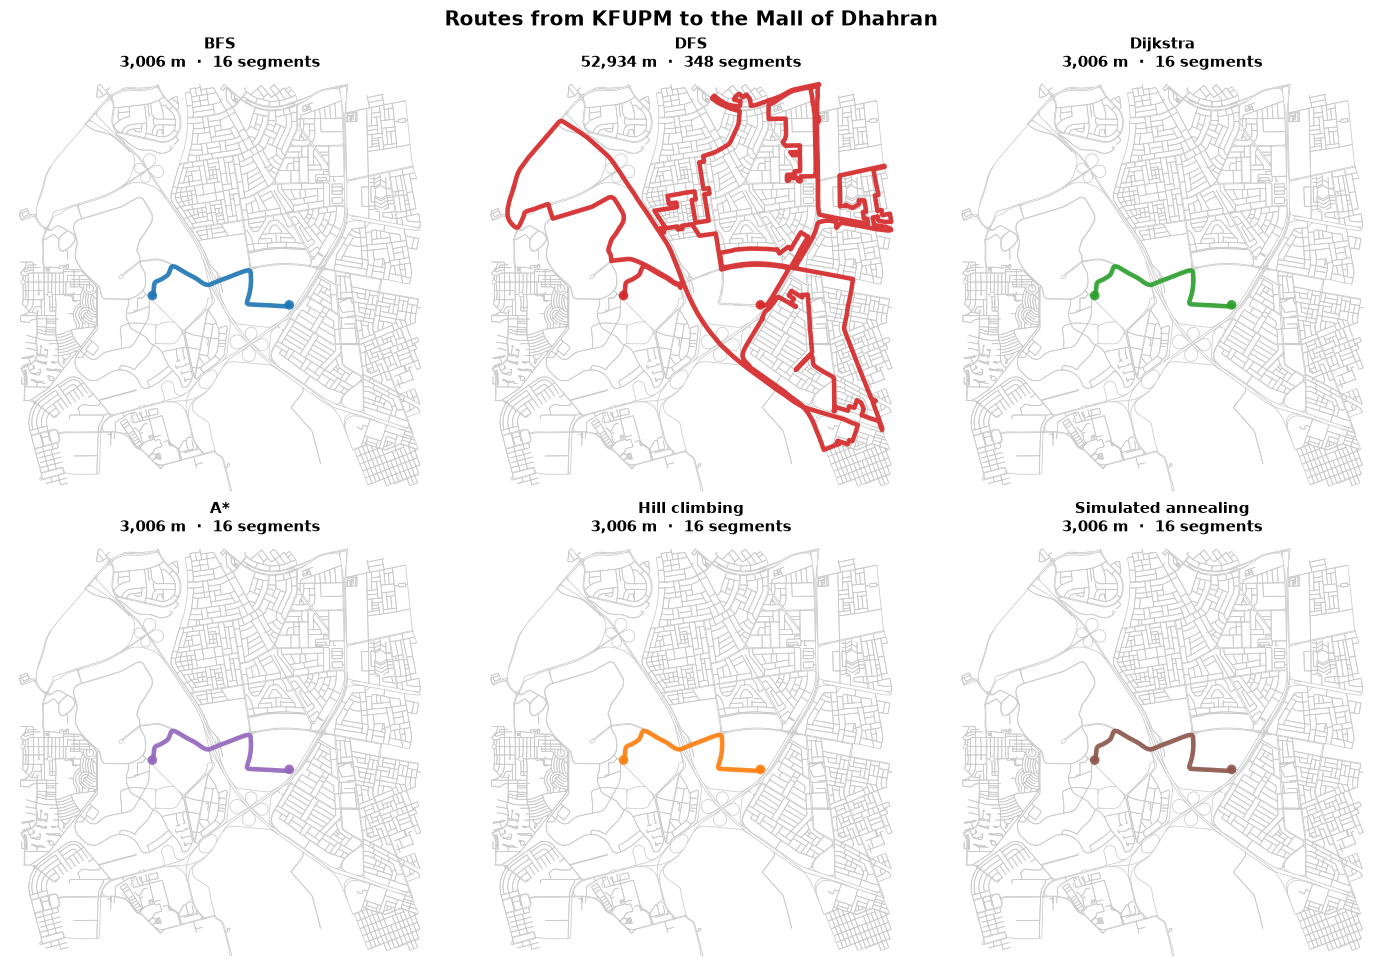

In [19]:
COLORS = {"BFS": "#1f77b4", "DFS": "#d62728", "Dijkstra": "#2ca02c", "A*": "#9467bd",
          "Hill climbing": "#ff7f0e", "Simulated annealing": "#8c564b"}

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (name, route) in zip(axes.ravel(), routes.items()):
    ox.plot_graph(G, ax=ax, node_size=0, edge_color="#c9c9c9", edge_linewidth=0.5,
                  bgcolor="white", show=False, close=False)
    ox.plot_graph_route(G, route, ax=ax, route_color=COLORS[name], route_linewidth=3,
                        route_alpha=0.9, orig_dest_size=40, show=False, close=False)
    r = res.loc[name]
    ax.set_title(f"{name}\n{r.best_m:,.0f} m  ·  {len(route) - 1} segments", fontsize=10)
fig.suptitle("Routes from KFUPM to the Mall of Dhahran", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "routes_grid.png"); plt.show()

In [20]:
m = folium.Map(location=mid, zoom_start=14, tiles=TILES, attr=TILES_ATTR)
for name, route in routes.items():
    gdf = ox.routing.route_to_gdf(G, route, weight="length")
    fg = folium.FeatureGroup(name=f"{name} — {route_cost(route):,.0f} m")
    for geom in gdf.geometry:
        folium.PolyLine([(yy, xx) for xx, yy in geom.coords], color=COLORS[name], weight=5,
                        opacity=0.8, tooltip=f"{name}: {route_cost(route):,.0f} m").add_to(fg)
    fg.add_to(m)
folium.Marker(orig_pt, tooltip="KFUPM", icon=folium.Icon(color="green", icon="graduation-cap", prefix="fa")).add_to(m)
folium.Marker(dest_pt, tooltip="Mall of Dhahran", icon=folium.Icon(color="red", icon="shopping-cart", prefix="fa")).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(MAPS / "routes.html")

### 4.8 Comparison

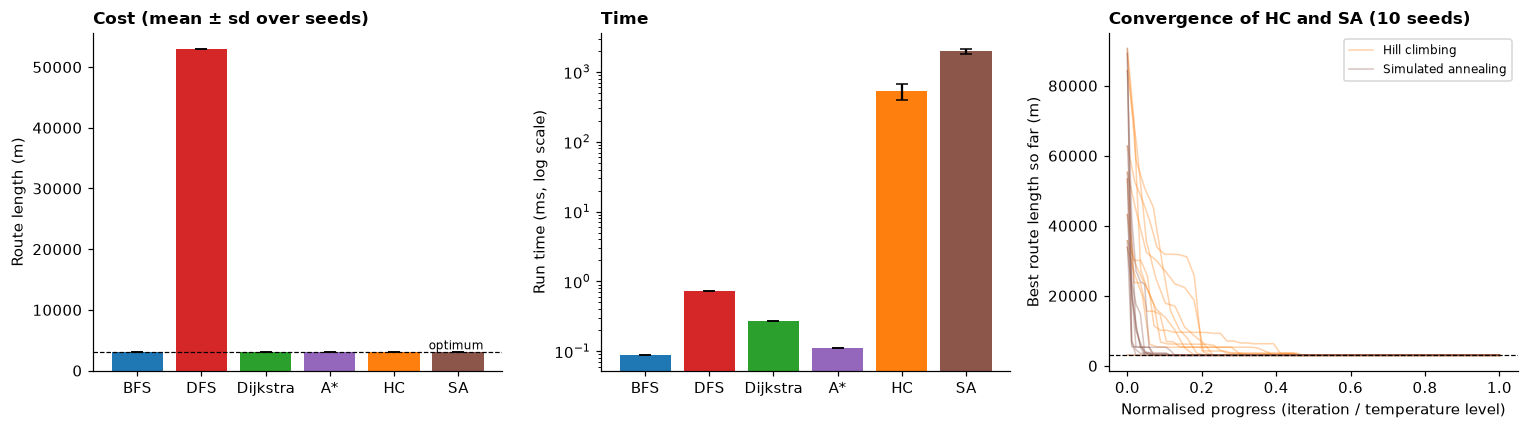

In [21]:
order = ["BFS", "DFS", "Dijkstra", "A*", "Hill climbing", "Simulated annealing"]
r = res.loc[order]
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14, 4))
cols = [COLORS[n] for n in order]
labels_short = ["BFS", "DFS", "Dijkstra", "A*", "HC", "SA"]

a1.bar(labels_short, r["cost_m"], yerr=r["cost_sd"], color=cols, capsize=4)
a1.axhline(nx_len, ls="--", color="k", lw=0.8)
a1.text(5.4, nx_len, " optimum", va="bottom", ha="right", fontsize=8)
a1.set_ylabel("Route length (m)"); a1.set_title("Cost (mean ± sd over seeds)", loc="left")

a2.bar(labels_short, r["time_ms"], yerr=r["time_sd"], color=cols, capsize=4)
a2.set_yscale("log"); a2.set_ylabel("Run time (ms, log scale)"); a2.set_title("Time", loc="left")

for n in ["Hill climbing", "Simulated annealing"]:
    for i, h in enumerate(histories[n]):
        xs = np.linspace(0, 1, len(h))
        a3.plot(xs, h, color=COLORS[n], alpha=0.35, lw=1, label=n if i == 0 else None)
a3.axhline(nx_len, ls="--", color="k", lw=0.8)
a3.set_xlabel("Normalised progress (iteration / temperature level)")
a3.set_ylabel("Best route length so far (m)"); a3.set_title("Convergence of HC and SA (10 seeds)", loc="left")
a3.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / "comparison.png"); plt.show()

**Observations — KFUPM → Mall of Dhahran.**

* **Dijkstra and A\*** both return the optimal route of **3,006 m** (confirmed against NetworkX). A\* reaches it after expanding only **51 nodes versus 259 for Dijkstra**, a 5× reduction, because the haversine heuristic steers it straight towards the mall.
* **BFS** happens to return the same route here: the optimal route is also the one with the fewest segments (16), because it runs along the arterial roads, where segments are long, instead of through local streets. This is luck, not a guarantee. The robustness check below shows BFS is usually suboptimal.
* **DFS** is fast, but its route is **52.9 km (17.6× the optimum, 348 segments)**. It follows one branch deep into the network and wanders across Dhahran and Khobar before it hits the destination, which shows clearly why DFS is unsuitable for routing.
* **Hill climbing and simulated annealing** both reach the optimum from every one of the 10 random starts, beginning from random routes of 35–90 km. They are three to four orders of magnitude slower (≈0.5 s and ≈2 s) than the exact methods, since every candidate route has to be built and evaluated. For point-to-point shortest paths on a graph of this size, informed exact search (A\*) is the clear choice. The metaheuristics are useful when the objective is not additive over edges (e.g. time-dependent or multi-criteria costs) or the problem is far larger.

### 4.9 Robustness check — 30 random origin–destination pairs

A single, fairly short trip cannot separate the algorithms well, so the comparison is repeated on 30 random origin–destination pairs from the same road graph (straight-line distance of at least 1.5 km). Each pair's optimum comes from Dijkstra. Deterministic methods are timed as the median of 5 repetitions. HC and SA use one seed per pair and the same settings as above.

,optimal_runs,mean_gap,median_gap,max_gap,mean_time_ms,mean_work
algorithm,,,,,,
BFS,6/30,7.39,2.84,41.15,0.63,1436.03
DFS,0/30,866.50,697.54,3233.02,1.13,1796.73
Dijkstra,30/30,0.00,0.00,0.00,2.19,1613.37
A*,30/30,0.00,0.00,0.00,1.50,543.67
Hill climbing,9/30,12.13,1.93,64.57,949.73,675.67
Simulated annealing,14/30,9.43,0.04,73.85,2335.84,1721.00


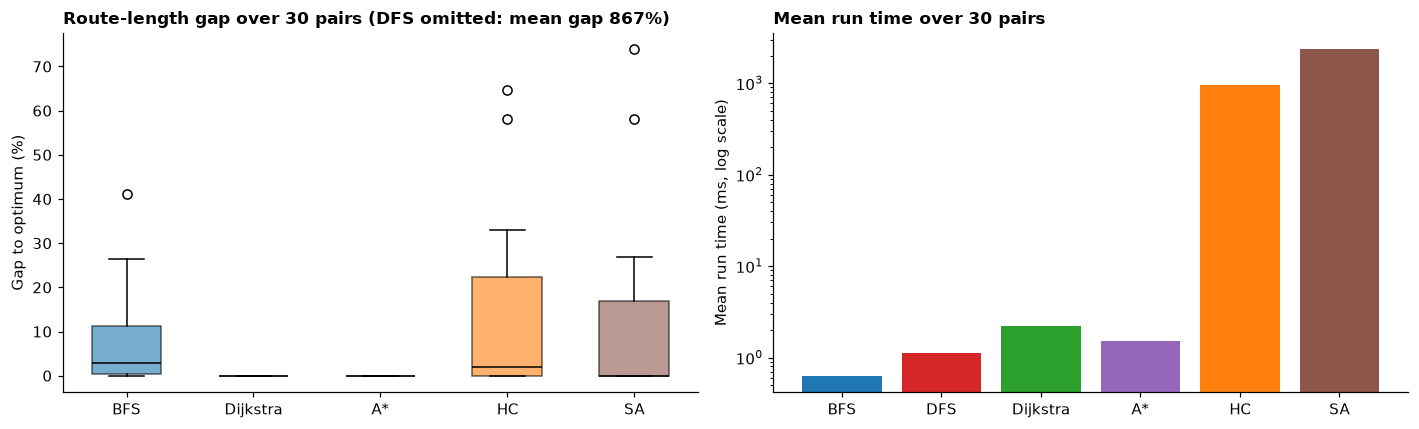

In [22]:
rng = random.Random(2026)
nodes = list(adj)
pairs = []
while len(pairs) < 30:
    a, b = rng.sample(nodes, 2)
    if haversine(a, b) >= 1500:
        pairs.append((a, b))

rows = []
for k, (a, b) in enumerate(pairs):
    opt = route_cost(dijkstra(a, b)[0])
    for name, fn in [("BFS", bfs), ("DFS", dfs), ("Dijkstra", dijkstra), ("A*", astar)]:
        (route, work), t = timed(fn, a, b, reps=5)
        rows.append(dict(pair=k, algorithm=name, cost=route_cost(route), opt=opt, time_ms=1e3 * t, work=work))
    for name, fn in [("Hill climbing", hill_climbing), ("Simulated annealing", simulated_annealing)]:
        (route, evals, _), t = timed(fn, a, b, seed=k)
        rows.append(dict(pair=k, algorithm=name, cost=route_cost(route), opt=opt, time_ms=1e3 * t, work=evals))

rob = pd.DataFrame(rows)
rob["gap_%"] = 100 * (rob["cost"] / rob["opt"] - 1)
rob.to_csv(DATA / "robustness_results.csv", index=False)
rob_summary = rob.groupby("algorithm").agg(
    optimal_runs=("gap_%", lambda g: f"{(g < 1e-6).sum()}/{len(g)}"),
    mean_gap=("gap_%", "mean"), median_gap=("gap_%", "median"), max_gap=("gap_%", "max"),
    mean_time_ms=("time_ms", "mean"), mean_work=("work", "mean")).loc[order]
display(rob_summary.round(2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
sub = [n for n in order if n != "DFS"]
bp = a1.boxplot([rob.loc[rob.algorithm == n, "gap_%"] for n in sub], patch_artist=True, widths=0.55,
                medianprops=dict(color="k"))
for patch, n in zip(bp["boxes"], sub):
    patch.set_facecolor(COLORS[n]); patch.set_alpha(0.6)
a1.set_xticks(range(1, len(sub) + 1), ["BFS", "Dijkstra", "A*", "HC", "SA"])
a1.set_ylabel("Gap to optimum (%)")
a1.set_title(f"Route-length gap over 30 pairs (DFS omitted: mean gap {rob_summary.loc['DFS', 'mean_gap']:,.0f}%)", loc="left")
a2.bar(["BFS", "DFS", "Dijkstra", "A*", "HC", "SA"], rob_summary["mean_time_ms"], color=[COLORS[n] for n in order])
a2.set_yscale("log"); a2.set_ylabel("Mean run time (ms, log scale)"); a2.set_title("Mean run time over 30 pairs", loc="left")
fig.tight_layout()
fig.savefig(FIGS / "robustness.png"); plt.show()

**Observations — robustness check (30 random trips).**

* **Dijkstra and A\*** are optimal on all 30 pairs. A\* expands about **one third as many nodes** (≈540 vs ≈1,610 nodes) and is faster on average.
* **BFS** is optimal on only **6 of 30** pairs, with a mean gap of 7.4 % and a worst case of 41 %. Minimising the number of segments is not the same as minimising distance.
* **DFS** has a mean gap of **867 %** (worst case 3,233 %), so it is effectively unusable for routing.
* **Simulated annealing beats hill climbing** on the same budget and neighbourhood: SA is optimal on **14/30** pairs (median gap **0.04 %**), against **9/30** (median gap 1.9 %) for HC. Hill climbing more often ends in a local optimum, a route that no single sub-path change can improve. SA's acceptance of uphill moves at high temperature lets it get out of these. Both still have occasional large outliers (≥ 58 %) on long trips, where the fixed budget is not enough. More moves per temperature or restarts would reduce them, at a further cost in time.
* **Time–quality trade-off:** A\* gives the best of both. BFS and DFS are cheap but unreliable, and HC and SA pay 400–1,000× more time for solutions that are, at best, as good as A\*'s.

## References

1. A. Khamis, *Optimization Algorithms: AI Techniques for Design, Planning, and Control Problems*, Manning, 2024 — chapters 3–5.
2. G. Boeing, "Modeling and analyzing urban networks and amenities with OSMnx," *Geographical Analysis*, 2025.
3. OpenStreetMap contributors, OpenStreetMap data © ODbL, retrieved through the Overpass API.
4. M. Ester, H.-P. Kriegel, J. Sander, X. Xu, "A density-based algorithm for discovering clusters in large spatial databases with noise," *KDD*, 1996.